In [1]:
import pandas as pd
df = pd.read_csv('INMET_NE_BA_A401_SALVADOR_01-01-2024_A_31-12-2024.CSV', sep = ';', encoding = 'latin1', skiprows=8)

In [2]:
df.head()

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,2024/01/01,0000 UTC,0,"1006,7","1006,7","1005,8",NaN,"26,8","22,8","26,8","26,6","22,8","22,6",79.0,78.0,79.0,66.0,"5,3","1,4"
1,2024/01/01,0100 UTC,0,"1006,9","1006,9","1006,7",NaN,"26,7","22,6","26,8","26,5","22,8","22,4",79.0,77.0,78.0,62.0,"5,5","1,2"
2,2024/01/01,0200 UTC,0,"1006,9","1007,1","1006,8",NaN,"26,5","22,9","26,7","26,4",23,"22,5",81.0,78.0,81.0,75.0,"4,6","1,2"
3,2024/01/01,0300 UTC,0,"1006,5","1006,9","1006,5",NaN,"26,3","22,7","26,5","26,2","22,9","22,6",82.0,80.0,81.0,69.0,"4,6","1,1"
4,2024/01/01,0400 UTC,0,"1006,5","1006,6","1006,5",NaN,26,"22,6","26,3","25,7","22,7","22,5",82.0,81.0,81.0,56.0,"4,2","0,8"


In [20]:
import pickle
with open('climate_data_2024.pkl', 'rb') as f:
    data = pickle.load(f)

data['date'] = pd.to_datetime(data['date'], format="%Y/%m/%d")
data = data[data['date'] >= "2024-03-01"]
data

,date,hour,precip
1440,2024-03-01,0000 UTC,0.0
1441,2024-03-01,0100 UTC,0.0
1442,2024-03-01,0200 UTC,0.0
1443,2024-03-01,0300 UTC,0.0
1444,2024-03-01,0400 UTC,0.0
...,...,...,...
8779,2024-12-31,1900 UTC,0.0
8780,2024-12-31,2000 UTC,0.0
8781,2024-12-31,2100 UTC,0.0
8782,2024-12-31,2200 UTC,0.0


Add day_id

In [15]:
# Converteix la columna 'date' a datetime
data['date'] = pd.to_datetime(data['date'], format='%Y/%m/%d')

# Crea 'day_id' incrementant cada dia diferent
data['day_id'] = (data['date'] - data['date'].min()).dt.days
import pandas as pd

# Converteix la columna 'date' a datetime
data['date'] = pd.to_datetime(data['date'], format='%Y/%m/%d')

# Crea 'day_id' incrementant cada dia diferent
data['day_id'] = (data['date'] - data['date'].min()).dt.days
data

,date,hour,precip,day_id
1440,2024-03-01,0000 UTC,0.0,0
1441,2024-03-01,0100 UTC,0.0,0
1442,2024-03-01,0200 UTC,0.0,0
1443,2024-03-01,0300 UTC,0.0,0
1444,2024-03-01,0400 UTC,0.0,0
...,...,...,...,...
8779,2024-12-31,1900 UTC,0.0,305
8780,2024-12-31,2000 UTC,0.0,305
8781,2024-12-31,2100 UTC,0.0,305
8782,2024-12-31,2200 UTC,0.0,305


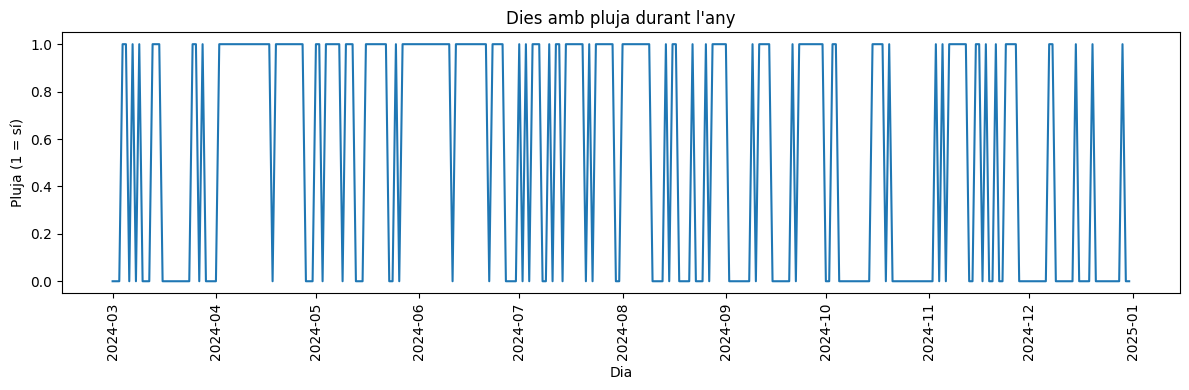

In [16]:
import matplotlib.pyplot as plt

# Assegurar format de data
data['date'] = pd.to_datetime(data['date'], format='%Y/%m/%d')

# Per cada dia, comprovar si en algun moment precip > 0
day_rain = data.groupby(data['date'].dt.date)['precip'].max() > 0

# Convertir a int per graficar (0 = no plou, 1 = plou)
vals = day_rain.astype(int)

plt.figure(figsize=(12,4))
plt.plot(vals.index, vals.values)
plt.xlabel("Dia")
plt.ylabel("Pluja (1 = sí)")
plt.title("Dies amb pluja durant l'any")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


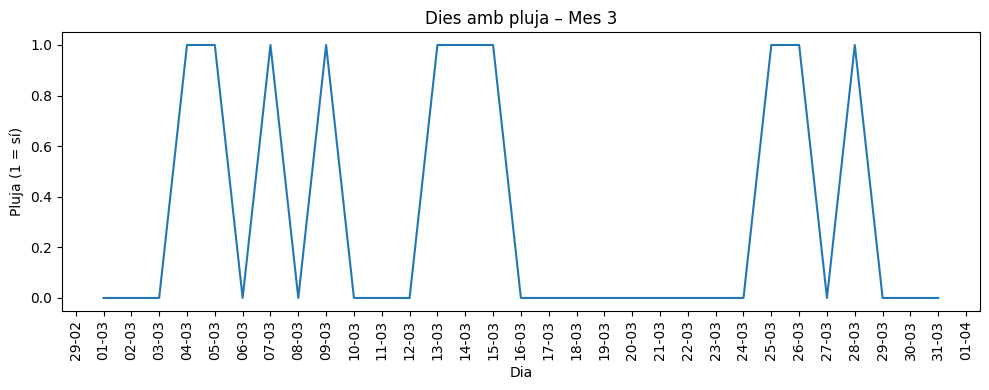

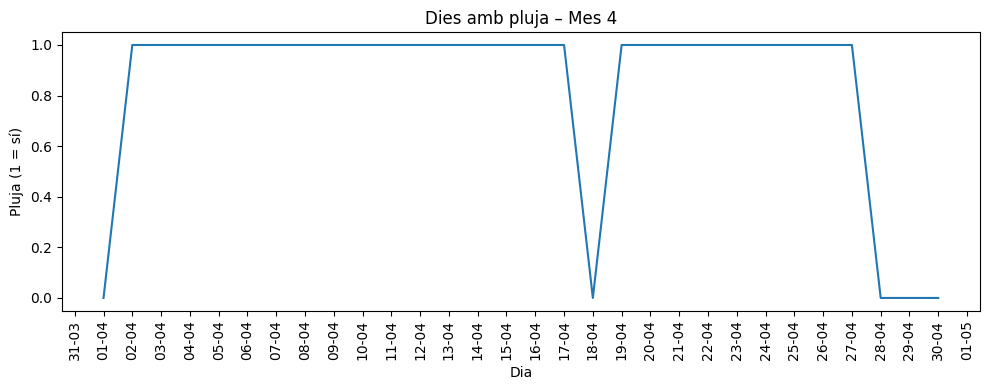

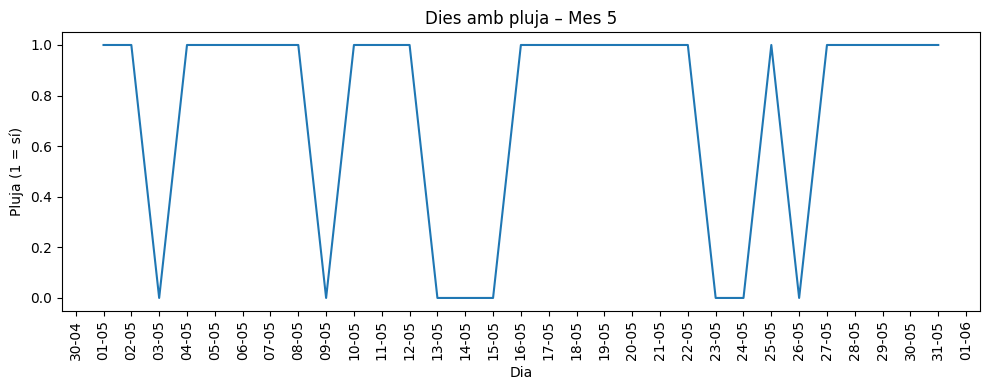

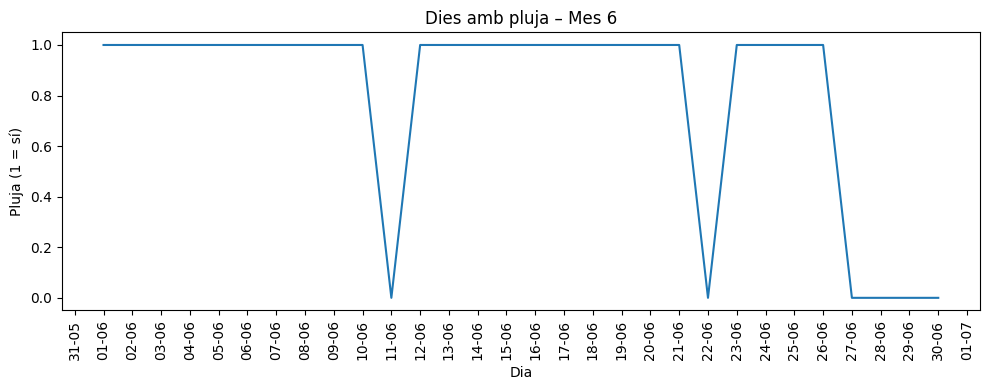

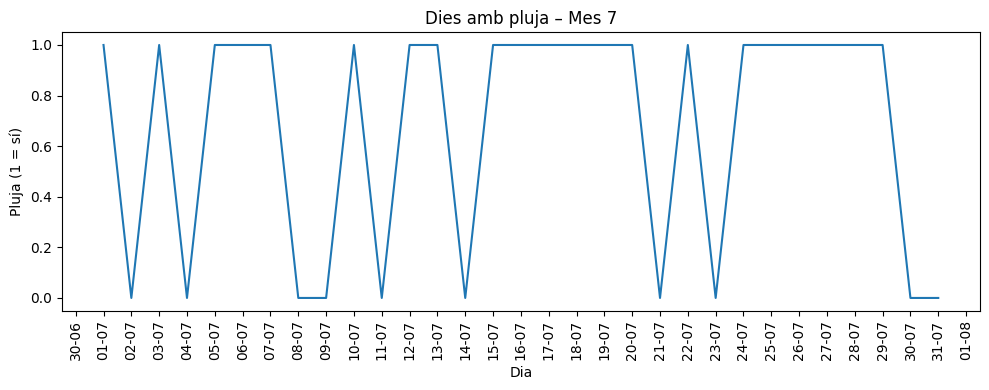

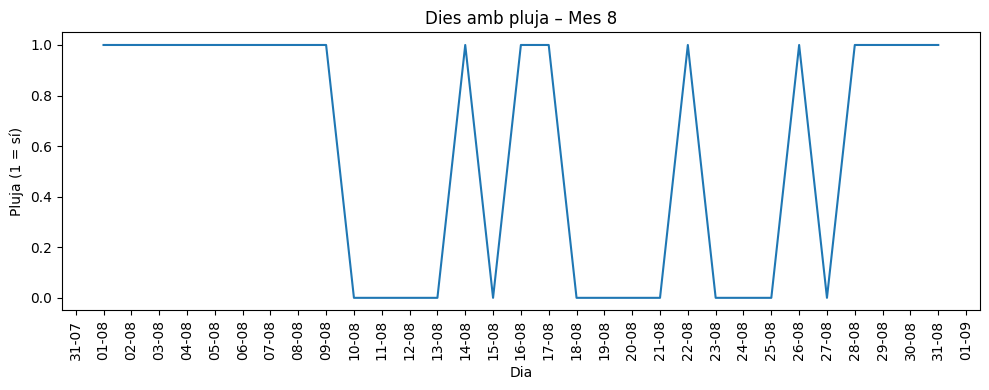

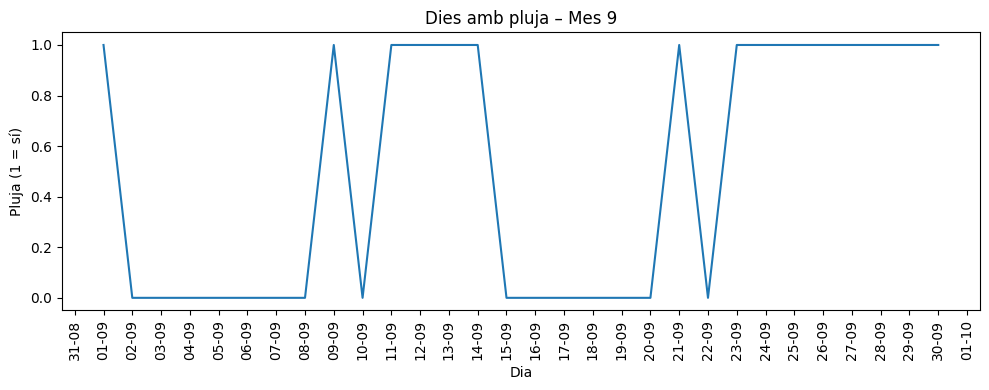

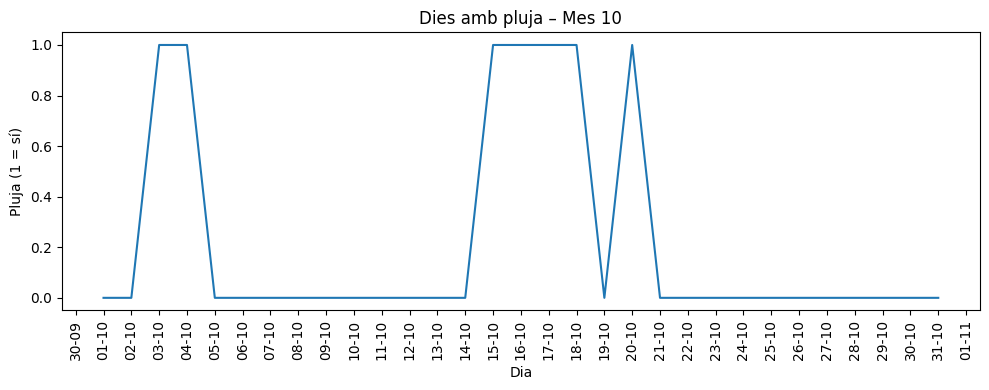

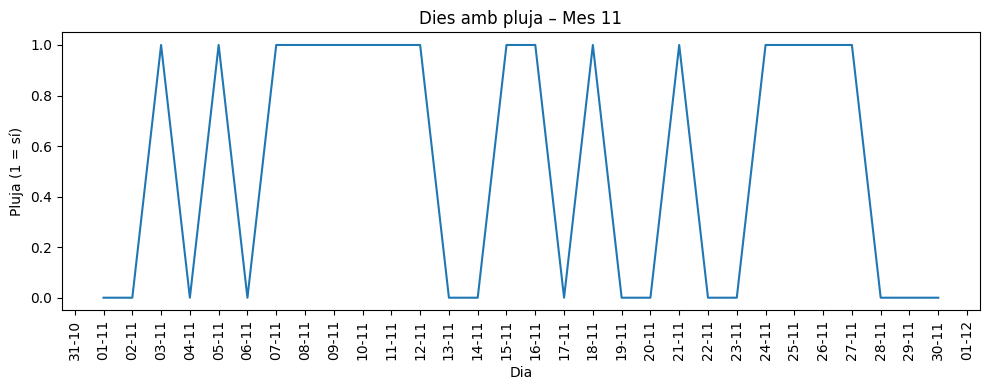

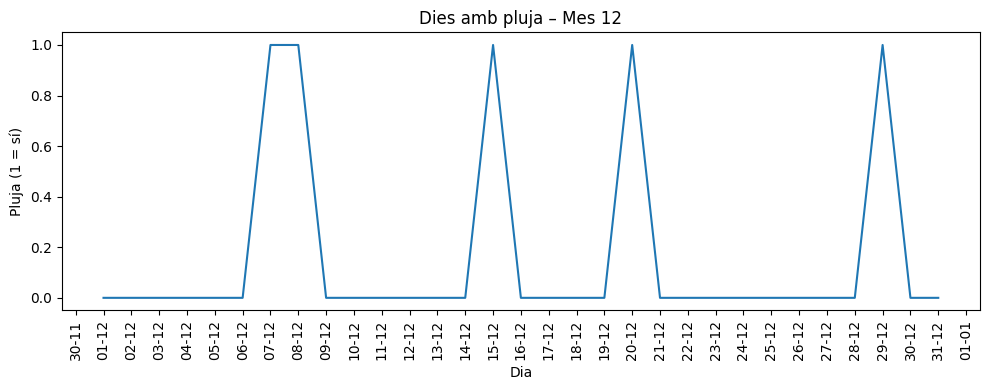

In [19]:
import matplotlib.dates as mdates

# Agrupar per dia si ha plogut
day_rain = (data.groupby(data['date'].dt.date)['precip'].max() > 0).astype(int)
day_rain.index = pd.to_datetime(day_rain.index)

# Fer un gràfic per cada mes
for month in range(1, 13):
    subset = day_rain[day_rain.index.month == month]

    if subset.empty:
        continue

    plt.figure(figsize=(10,4))
    plt.plot(subset.index, subset.values)

    # ---- MOSTRAR TOTES LES DATES ----
    plt.gca().xaxis.set_major_locator(mdates.DayLocator())     # un tick per cada dia
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.title(f"Dies amb pluja – Mes {month}")
    plt.xlabel("Dia")
    plt.ylabel("Pluja (1 = sí)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()